In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sn

In [2]:
df=pd.read_csv("C:/Users/Praneeth Mahaan/Zomato-data.csv")
df

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1/5,775,800,Buffet
1,Spice Elephant,Yes,No,4.1/5,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8/5,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7/5,88,300,Buffet
4,Grand Village,No,No,3.8/5,166,600,Buffet
...,...,...,...,...,...,...,...
143,Melting Melodies,No,No,3.3/5,0,100,Dining
144,New Indraprasta,No,No,3.3/5,0,150,Dining
145,Anna Kuteera,Yes,No,4.0/5,771,450,Dining
146,Darbar,No,No,3.0/5,98,800,Dining


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 148 entries, 0 to 147
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   name                         148 non-null    str  
 1   online_order                 148 non-null    str  
 2   book_table                   148 non-null    str  
 3   rate                         148 non-null    str  
 4   votes                        148 non-null    int64
 5   approx_cost(for two people)  148 non-null    int64
 6   listed_in(type)              148 non-null    str  
dtypes: int64(2), str(5)
memory usage: 8.2 KB


In [6]:
df['rate'] = df['rate'].str.replace('/5', '', regex=False)
df

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1,775,800,Buffet
1,Spice Elephant,Yes,No,4.1,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7,88,300,Buffet
4,Grand Village,No,No,3.8,166,600,Buffet
...,...,...,...,...,...,...,...
143,Melting Melodies,No,No,3.3,0,100,Dining
144,New Indraprasta,No,No,3.3,0,150,Dining
145,Anna Kuteera,Yes,No,4.0,771,450,Dining
146,Darbar,No,No,3.0,98,800,Dining


In [14]:
df['rate']=df['rate'].astype('float')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 148 entries, 0 to 147
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   name                         148 non-null    str    
 1   online_order                 148 non-null    str    
 2   book_table                   148 non-null    str    
 3   rate                         148 non-null    float64
 4   votes                        148 non-null    int64  
 5   approx_cost(for two people)  148 non-null    int64  
 6   listed_in(type)              148 non-null    str    
dtypes: float64(1), int64(2), str(4)
memory usage: 8.2 KB


In [15]:
df['listed_in(type)'].value_counts()

listed_in(type)
Dining    110
Cafes      23
other       8
Buffet      7
Name: count, dtype: int64

In [8]:
votes_by_type = df.groupby('listed_in(type)')['votes'].mean().reset_index()
votes_by_type.columns = ['type', 'avg_votes']
votes_by_type = votes_by_type.sort_values('avg_votes', ascending=False)
print(votes_by_type)

     type    avg_votes
3   other  1170.875000
0  Buffet   432.571429
1   Cafes   279.739130
2  Dining   185.118182


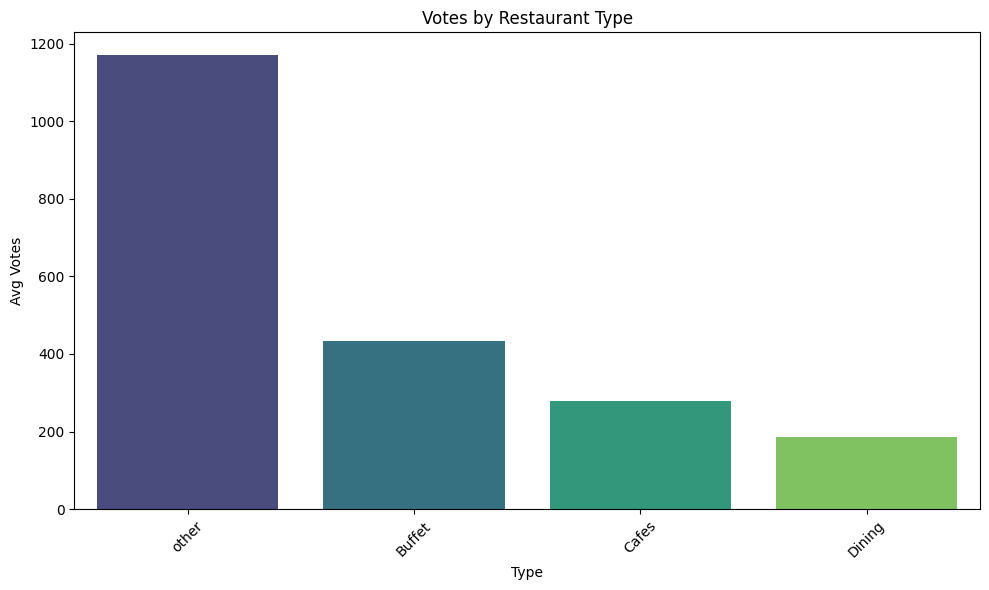

In [9]:
fig, ax = plt.subplots(figsize=(10, 6))
sn.barplot(data=votes_by_type, x='type', y='avg_votes', hue='type',palette='viridis',legend=False)
ax.set_title('Votes by Restaurant Type')
ax.set_xlabel('Type')
ax.set_ylabel('Avg Votes')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('Which_type is winning', dpi=300, bbox_inches='tight')
plt.show()

In [10]:
df[df['votes'] == df['votes'].max()][['name', 'votes']]

,name,votes
38,Empire Restaurant,4884


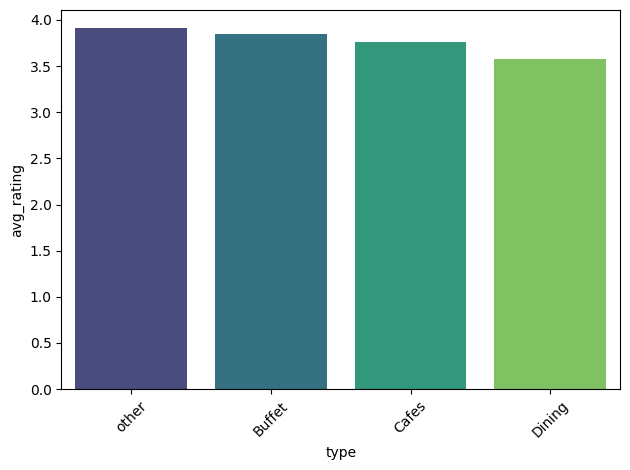

In [16]:
ratings_by_type = df.groupby('listed_in(type)')['rate'].mean().reset_index()
ratings_by_type.columns = ['type', 'avg_rating']
ratings_by_type = ratings_by_type.sort_values('avg_rating', ascending=False)

sn.barplot(data=ratings_by_type, x='type', y='avg_rating', hue='type', palette='viridis', legend=False)
ax.set_title('Ratings by Restaurant Type')
ax.set_xlabel('Type')
ax.set_ylabel('Avg Rating')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('Rating_game', dpi=300, bbox_inches='tight')
plt.show()

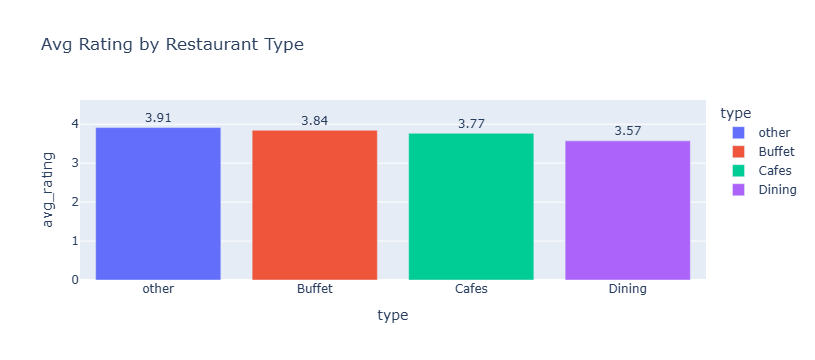

In [27]:
import plotly.express as px

fig = px.bar(ratings_by_type, x='type', y='avg_rating',
             color='type',
             title='Avg Rating by Restaurant Type',
             text='avg_rating')


fig.update_traces(texttemplate='%{text:.2f}', textposition='outside')
fig.write_html('rating_by_Restaurant_type.html')
fig.show()

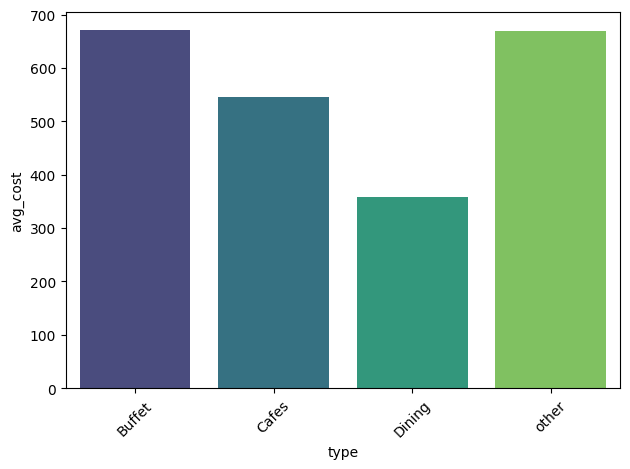

In [18]:
cost_by_type = df.groupby('listed_in(type)')['approx_cost(for two people)'].mean().reset_index()
cost_by_type.columns = ['type', 'avg_cost']

sn.barplot(data=cost_by_type, x='type', y='avg_cost', hue='type', palette='viridis', legend=False)
ax.set_title('Cost by Restaurant Type')
ax.set_xlabel('Type')
ax.set_ylabel('Avg Cost')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('Cost_game', dpi=300, bbox_inches='tight')
plt.show()

<Axes: xlabel='online_order', ylabel='rate'>

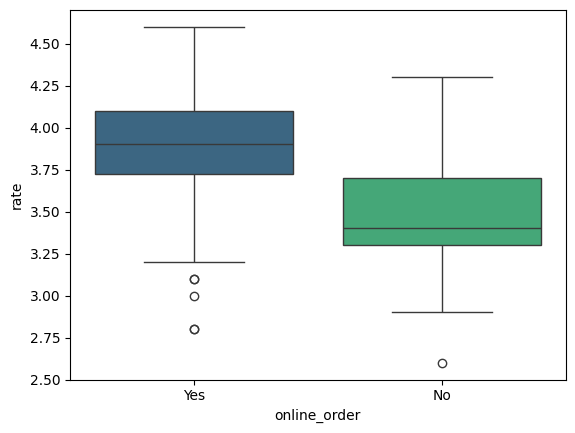

In [23]:
sn.boxplot(data=df, x='online_order', y='rate',hue='online_order', palette='viridis',legend=False)

In [24]:
df['online_order'].value_counts()
df['online_order'].value_counts(normalize=True) * 100  # percentage

online_order
No     60.810811
Yes    39.189189
Name: proportion, dtype: float64

In [ ]:
fig = px.bar(ratings_by_type, x='type', y='avg_rating',
             color='type',
             title='Avg Rating by Restaurant Type',
             text='avg_rating')

fig.update_traces(texttemplate='%{text:.2f}', textposition='outside')
fig.show()

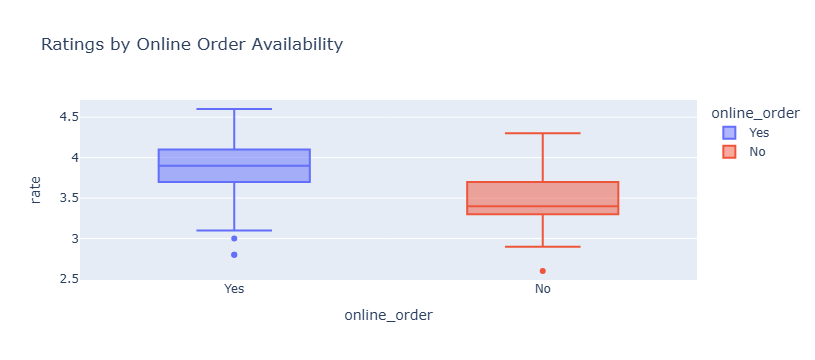

In [26]:
import plotly.express as px

fig = px.box(df, x='online_order', y='rate', color='online_order',
              title='Ratings by Online Order Availability')
fig.write_html('rating_by_online_order.html')
fig.show()

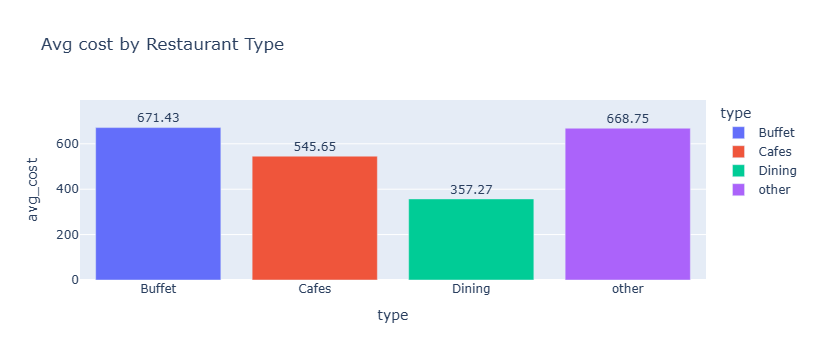

In [28]:
fig = px.bar(cost_by_type, x='type', y='avg_cost',
             color='type',
             title='Avg cost by Restaurant Type',
             text='avg_cost')


fig.update_traces(texttemplate='%{text:.2f}', textposition='outside')
fig.write_html('cost_by_Restaurant_type.html')
fig.show()